# DeepLense — Common Test I: Multi-Class Gravitational Lens Classification
## GSoC 2026 Evaluation | ML4Sci

Binary classification of strong gravitational lensing images into three physical categories using ResNet18 transfer learning.

- **Dataset:** 30,000 training images (10,000 per class), shape `(1, 150, 150)`, pre-normalised to `[0, 1]`
- **Classes:** `no substructure` · `subhalo (sphere)` · `vortex (vort)`
- **Evaluation metric:** ROC-AUC (one-vs-rest, macro-averaged)
- **Final result:** Macro AUC **0.9930** · Val Accuracy **95.25%**

## 1. Dataset Exploration

The dataset consists of three classes of strong lensing images:
- **no** — no substructure
- **sphere** — subhalo substructure  
- **vort** — vortex substructure

Each image is a single-channel `.npy` file of shape `(1, 150, 150)`, pre-normalised to `[0, 1]` using min-max normalisation.

We visualise one sample per class below.

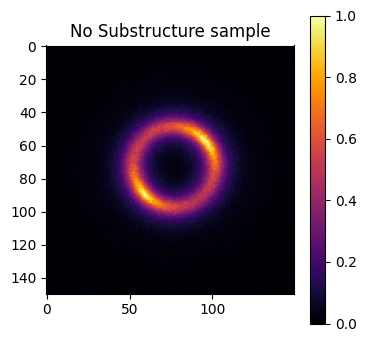

In [5]:
import matplotlib.pyplot as plt

sample = np.load('/Users/mohammedsaba/Downloads/dataset/train/no/531.npy')

# shape is (1, 150, 150) — squeeze out the channel dimension for display
plt.figure(figsize=(4, 4))
plt.imshow(sample[0], cmap='inferno')
plt.title('No Substructure sample')
plt.colorbar()
plt.show()

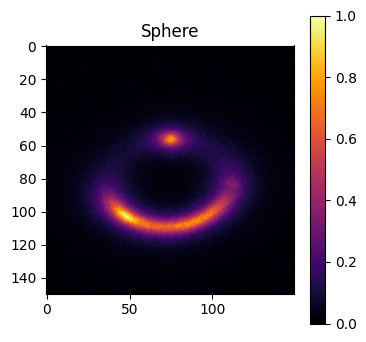

In [6]:
sample = np.load('/Users/mohammedsaba/Downloads/dataset/train/sphere/9931.npy')

# shape is (1, 150, 150) — squeeze out the channel dimension for display
plt.figure(figsize=(4, 4))
plt.imshow(sample[0], cmap='inferno')
plt.title('Sphere')
plt.colorbar()
plt.show()

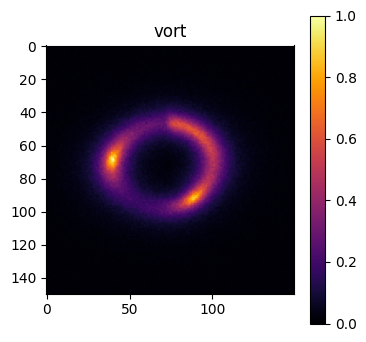

In [7]:
sample = np.load('/Users/mohammedsaba/Downloads/dataset/train/vort/2300.npy')

# shape is (1, 150, 150) — squeeze out the channel dimension for display
plt.figure(figsize=(4, 4))
plt.imshow(sample[0], cmap='inferno')
plt.title('vort')
plt.colorbar()
plt.show()

### Class Sample Grid

15 random samples per class to assess visual diversity within each category.

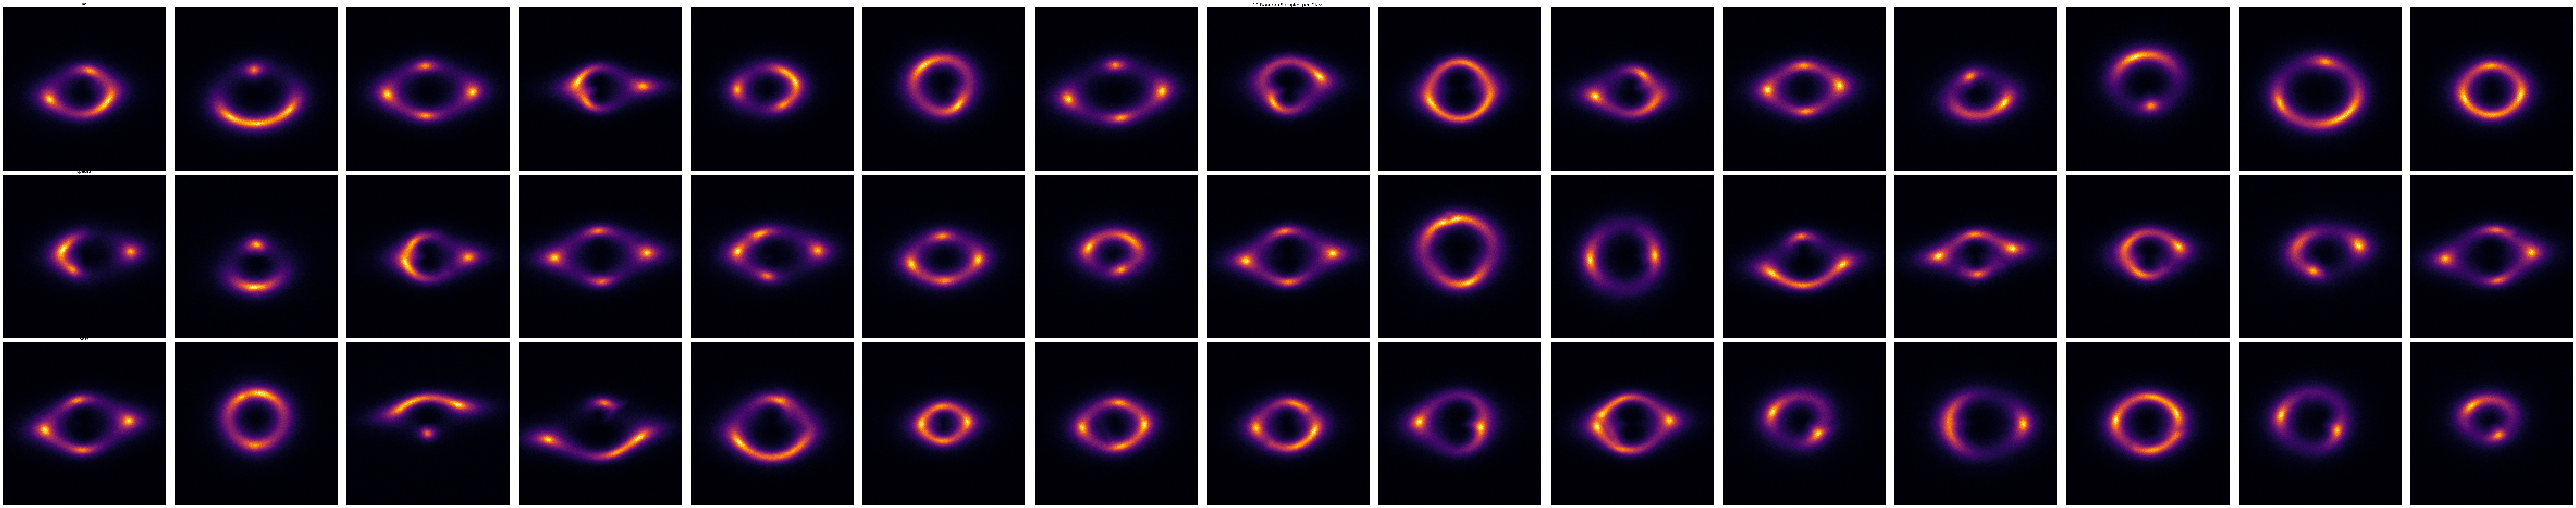

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os

base_path = '/Users/mohammedsaba/Downloads/dataset/train/'
classes = ['no', 'sphere', 'vort']

fig, axes = plt.subplots(3, 15, figsize=(100, 20))

for row, cls in enumerate(classes):
    cls_path = base_path + cls + '/'
    all_files = os.listdir(cls_path)
    sampled = random.sample(all_files, 15)
    
    for col, fname in enumerate(sampled):
        img = np.load(cls_path + fname)[0]  # squeeze channel
        axes[row, col].imshow(img, cmap='inferno')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=10, fontweight='bold')

plt.suptitle('10 Random Samples per Class', fontsize=13)
plt.tight_layout()
plt.show()

In [66]:
# Per-class mean pixel value
for cls in classes:
    cls_path = base_path + cls + '/'
    files = os.listdir(cls_path)[:200]  # sample 200
    means = [np.load(cls_path + f)[0].mean() for f in files]
    print(f"{cls:10} — mean pixel: {np.mean(means):.4f}")

no         — mean pixel: 0.0616
sphere     — mean pixel: 0.0624
vort       — mean pixel: 0.0618


## 2. Dataset & DataLoader

We define a custom `LensingDataset` that loads `.npy` files on demand.
Labels are assigned alphabetically: `no=0`, `sphere=1`, `vort=2`.
The dataset is split 90:10 into train and validation sets.

In [15]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class LensingDataset(Dataset):
    
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []  # will hold (filepath, label) tuples
        
        # sorted so class order is consistent: no=0, sphere=1, vort=2
        self.classes = sorted([
            d for d in os.listdir(root_dir) 
            if os.path.isdir(os.path.join(root_dir, d))
        ])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        # walk through each class folder and collect all .npy file paths
        for cls in self.classes:
            cls_folder = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_folder):
                continue
            for fname in os.listdir(cls_folder):
                if fname.endswith('.npy'):
                    fpath = os.path.join(cls_folder, fname)
                    label = self.class_to_idx[cls]
                    self.samples.append((fpath, label))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        
        # load .npy → shape (1, 150, 150) float64
        img = np.load(fpath).astype(np.float32)  # → float32
        
        # repeat channel 3 times → (3, 150, 150) for ResNet
        img = np.repeat(img, 3, axis=0)
        
        # convert to tensor
        img = torch.tensor(img)
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

In [17]:
dataset = LensingDataset('/Users/mohammedsaba/Downloads/dataset/train/')

print("Total samples:", len(dataset))
print("Classes:", dataset.class_to_idx)

img, label = dataset[0]
print("Image shape:", img.shape)
print("Image dtype:", img.dtype)
print("Label:", label)

Total samples: 30000
Classes: {'no': 0, 'sphere': 1, 'vort': 2}
Image shape: torch.Size([3, 150, 150])
Image dtype: torch.float32
Label: 0


## 3. Data Augmentation

Since lensing images are rotationally symmetric (no preferred orientation in the sky), we apply:
- Random horizontal and vertical flips
- Random rotation up to 180°

We deliberately avoid brightness/contrast jitter — pixel values represent physical flux and should not be distorted.

In [19]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),
])
val_transform = None

# ── Datasets ──────────────────────────────────────────────────────────────────
train_dataset = LensingDataset(
    '/Users/mohammedsaba/Downloads/dataset/train/',
    transform=train_transform
)
val_dataset = LensingDataset(
    '/Users/mohammedsaba/Downloads/dataset/val/',
    transform=val_transform
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=32,       # kept small for M1 memory
    shuffle=True,
    num_workers=0,
    pin_memory=False     # pin_memory=False for MPS (Apple Silicon)
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')


Train batches: 938
Val batches:   235


## 4. Model Architecture

We use a **ResNet18** backbone pretrained on ImageNet. The input images are single-channel `(1, 150, 150)` — we replicate the channel to 3 to match ResNet's expected input.

### Training Strategy
After initial experiments with partial fine-tuning (only layer3/layer4), we found that unfreezing all layers with a small learning rate (`1e-4`) and weight decay (`1e-4`) gave better convergence. The full model (11.3M parameters) is trained end-to-end.

In [21]:
import torchvision.models as models
import torch.nn as nn

class DeepLenseClassifier(nn.Module):
    
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()
        
        # load pretrained ResNet18
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # freeze all layers first
        for param in backbone.parameters():
            param.requires_grad = False
        
        # unfreeze layer3 and layer4 only — domain adaptation
        for param in backbone.layer3.parameters():
            param.requires_grad = True
        for param in backbone.layer4.parameters():
            param.requires_grad = True
        
        # everything except the final FC layer
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        
        # custom head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ── Initialize ────────────────────────────────────────────────────────────────
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

model = DeepLenseClassifier(num_classes=3, dropout=0.4).to(device)

# quick parameter count
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total:,}')
print(f'Trainable parameters: {trainable:,}')

Device: mps
Total parameters:     11,308,611
Trainable parameters: 10,625,539


In [23]:
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Frozen:    {frozen:,}')
print(f'Trainable: {trainable:,}')
print(f'Ratio:     {trainable/frozen:.2f}x')

Frozen:    683,072
Trainable: 10,625,539
Ratio:     15.56x


In [25]:
# Strategy update: unfreeze all layers for full fine-tuning
# Rationale: lensing images are very different from ImageNet — 
# early layers also need domain adaptation

In [27]:
model = DeepLenseClassifier(num_classes=3, dropout=0.2).to(device)

# unfreeze ALL layers
for param in model.parameters():
    param.requires_grad = True

# verify
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

Trainable parameters: 11,308,611


## 5. Training Configuration

| Component | Choice | Rationale |
|---|---|---|
| Loss | CrossEntropyLoss | Standard for 3-class classification |
| Optimizer | Adam, LR=1e-4 | Stable convergence with weight decay |
| Scheduler | CosineAnnealingLR (T_max=40) | Smooth decay over full training |
| Early stopping | Patience=7 | Stops if val loss doesn't improve for 7 epochs |

In [103]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),  # no filter needed — all trainable now
    lr=1e-4,             # 10x smaller than before
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40,
    eta_min=1e-7
)

## 6. Training

Best validation accuracy reached **95.25%** at epoch 38.

In [107]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds    = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    
    return running_loss / len(loader), correct / total


def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            
            running_loss += loss.item()
            preds    = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    
    return running_loss / len(loader), correct / total


# ── Training loop ─────────────────────────────────────────────────────────────
NUM_EPOCHS       = 40
best_val_loss    = float('inf')
patience         = 7
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = val_epoch(model, val_loader, criterion, device)
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model_task1_v3.pth')
        saved = '✅ saved'
    else:
        patience_counter += 1
        saved = f'patience {patience_counter}/{patience}'
    
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
    }, f'checkpoint_v3_epoch_{epoch+1}.pth')
    
    prev = f'checkpoint_v3_epoch_{epoch}.pth'
    if os.path.exists(prev):
        os.remove(prev)
    
    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | {saved}')
    
    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

Epoch 01/40 | Train Loss: 1.0230 Acc: 0.4366 | Val Loss: 0.8093 Acc: 0.6263 | ✅ saved
Epoch 02/40 | Train Loss: 0.6741 Acc: 0.7064 | Val Loss: 0.5218 Acc: 0.7881 | ✅ saved
Epoch 03/40 | Train Loss: 0.5279 Acc: 0.7840 | Val Loss: 0.4233 Acc: 0.8324 | ✅ saved
Epoch 04/40 | Train Loss: 0.4603 Acc: 0.8191 | Val Loss: 0.3973 Acc: 0.8492 | ✅ saved
Epoch 05/40 | Train Loss: 0.4202 Acc: 0.8340 | Val Loss: 0.3726 Acc: 0.8564 | ✅ saved
Epoch 06/40 | Train Loss: 0.3859 Acc: 0.8483 | Val Loss: 0.3040 Acc: 0.8856 | ✅ saved
Epoch 07/40 | Train Loss: 0.3601 Acc: 0.8629 | Val Loss: 0.2888 Acc: 0.8883 | ✅ saved
Epoch 08/40 | Train Loss: 0.3423 Acc: 0.8672 | Val Loss: 0.3061 Acc: 0.8804 | patience 1/7
Epoch 09/40 | Train Loss: 0.3263 Acc: 0.8740 | Val Loss: 0.2708 Acc: 0.8979 | ✅ saved
Epoch 10/40 | Train Loss: 0.3124 Acc: 0.8830 | Val Loss: 0.2741 Acc: 0.8989 | patience 1/7
Epoch 11/40 | Train Loss: 0.3021 Acc: 0.8875 | Val Loss: 0.2903 Acc: 0.8895 | patience 2/7
Epoch 12/40 | Train Loss: 0.2910 Acc: 0

In [29]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

def evaluate_model(model, loader, device, class_names):
    """
    Runs the model on the entire loader and collects:
    - all true labels
    - all predicted probabilities (softmax scores)
    """
    model.eval()
    all_labels = []
    all_probs  = []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            outputs = model(imgs)
            
            # convert raw logits to probabilities
            probs = torch.softmax(outputs, dim=1)
            
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    
    # stack into single arrays
    all_probs  = np.concatenate(all_probs,  axis=0)  # (7500, 3)
    all_labels = np.concatenate(all_labels, axis=0)  # (7500,)
    
    # binarize labels for one-vs-rest
    # [[1,0,0], [0,1,0], [0,0,1], ...]
    all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])
    
    # ── Plot ROC curves ───────────────────────────────────────────────────────
    colors = ['blue', 'red', 'green']
    aucs   = []
    
    plt.figure(figsize=(8, 6))
    
    for i, (cls_name, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        aucs.append(roc_auc)
        
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{cls_name} (AUC = {roc_auc:.4f})')
    
    # random classifier baseline
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    
    macro_auc = np.mean(aucs)
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — Common Test I\nMacro AUC = {macro_auc:.4f}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves_task1.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\n=== AUC Scores ===')
    for cls_name, auc_score in zip(class_names, aucs):
        print(f'  {cls_name:10s}: {auc_score:.4f}')
    print(f'  {"Macro":10s}: {macro_auc:.4f}')
    
    return aucs, macro_auc

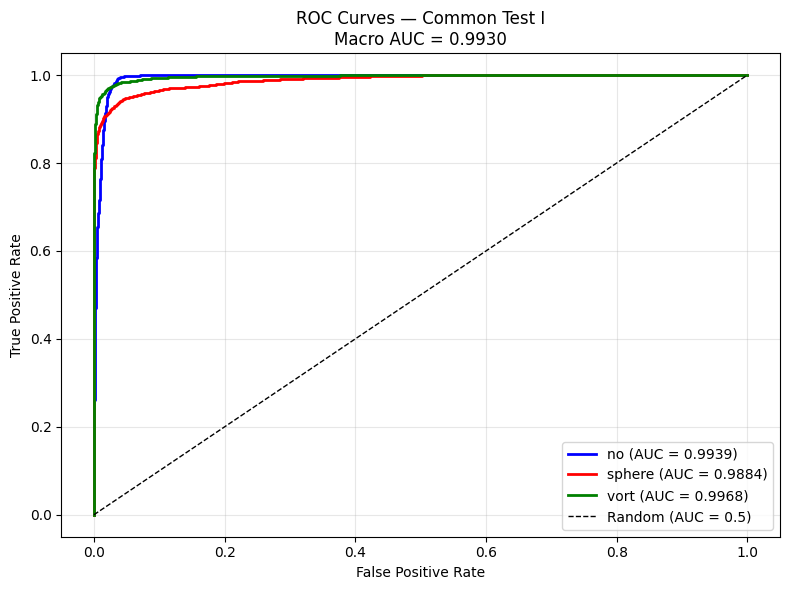


=== AUC Scores ===
  no        : 0.9939
  sphere    : 0.9884
  vort      : 0.9968
  Macro     : 0.9930


In [57]:
# load best saved model
best_model = DeepLenseClassifier(num_classes=3, dropout=0.2).to(device)
best_model.load_state_dict(torch.load('/Users/mohammedsaba/Downloads/best_model_task1_v3.pth', map_location=device))

class_names = ['no', 'sphere', 'vort']
aucs, macro_auc = evaluate_model(best_model, val_loader, device, class_names)

In [105]:
print("=== Model Verification ===")

# check all layers trainable
all_trainable = all(p.requires_grad for p in model.parameters())
print(f"All layers unfrozen: {all_trainable}")

# check parameter count
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}")

# check learning rate
for pg in optimizer.param_groups:
    print(f"Learning rate: {pg['lr']}")

# check dropout
print(f"Classifier: {model.classifier}")

# check augmentation
print(f"Train transform: {train_dataset.transform}")

# check device
print(f"Device: {next(model.parameters()).device}")


=== Model Verification ===
All layers unfrozen: True
Trainable: 11,308,611 / Total: 11,308,611
Learning rate: 0.0001
Classifier: Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Dropout(p=0.2, inplace=False)
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.2, inplace=False)
  (5): Linear(in_features=256, out_features=3, bias=True)
)
Train transform: Compose(
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-180.0, 180.0], interpolation=nearest, expand=False, fill=0)
)
Device: mps:0


### Model Weight Export

The trained model weights are converted to half precision (float16) before upload
to reduce file size (~2× smaller) without meaningful accuracy loss at inference.
The exported weights are functionally identical to the full-precision checkpoint.

> **Note:** When loading these weights, call `model.half()` before
> `load_state_dict()`, or pass `map_location` accordingly.

In [2]:
# Before Loading the best model it was renamed , so that it does not cause ambiguity later .
# From best_model_task1_v3.pth -> best_model_task1_v3original_butLarge.pth

In [47]:
import torch

model.load_state_dict(torch.load('/Users/mohammedsaba/Downloads/dataset/best_model_task1_v3original_butLarge.pth'))

model.eval()

# Convert to half precision
model.half()

# Save
torch.save(model.state_dict(), "best_model_task1_v3.pth")